In [1]:
import sys
from pathlib import Path
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
)
from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import HistGradientBoostingClassifier


# Sklearn - models use with voting classifier
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Model saving
import os
import joblib

# Settings
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

root_path = Path.cwd().parent 
if str(root_path) not in sys.path:
    sys.path.insert(0, str(root_path))

from pipelines.data_pipeline import  split_data, get_data_and_process_target, scale_features, label_encode_target
from pipelines.Classification_pipelines import evaluate_classification_model, run_hist_gradient_boosting, run_random_forest, run_decision_tree,run_gradient_boosting, run_knn, run_svm_linear, run_voting_classifier, plot_feature_importance, run_xgb_classifier_feature
print("Libraries imported successfully!")

Libraries imported successfully!


### Model 1: Traffic Accident Severity — Traditional ML

- Multi-class classification: predict accident severity (1-4 scale)
- This dataset has significant class imbalance — your approach to handling it will be a key evaluation criterion. **Weighted F1 is the real evaluation metric**, not accuracy.
- Use classical ML algorithms (XGBoost, Random Forest, Gradient Boosting, etc.)
- Must be interpretable — city planners need to understand WHY an intersection is flagged as high-risk
- **Minimum Benchmark:** Accuracy > 70%, weighted F1 > 0.55
- **Stretch Goal:** Accuracy > 80%, weighted F1 > 0.70
- **Required:** SHAP or feature importance analysis — which factors most predict severe accidents?

## Load Processed Data

In [ ]:
# Initialize your app variables
TARGET = 'Severity'

# Use the component to load data
df, target_stats = get_data_and_process_target("city_traffic_processed.csv", target_column=TARGET)

# Access your range and std whenever you need them
if target_stats:
    print(f"\nReady to process models for {TARGET}...")

# Initialize
all_results = []
trained_models = {}

--- Data Successfully Loaded ---
Data shape: (500000, 99)
Target Column: 'Severity'
Target range: 3.00
Target std: 0.49

Ready to process models for Severity...


In [3]:
# Check class balance
class_counts = df[TARGET].value_counts()
class_percentages = df[TARGET].value_counts(normalize=True) * 100

print("Class Distribution:")
for cat in class_counts.index:
    print(f"{cat}: {class_counts[cat]} ({class_percentages[cat]:.1f}%)")

# Check for severe imbalance
min_class_pct = class_percentages.min()
if min_class_pct < 10:
    print(f"\nWarning: Smallest class is only {min_class_pct:.1f}% of data.")
    print("Consider adjusting your binning strategy.")
else:
    print(f"\nClass balance looks reasonable!")

Class Distribution:
2: 398335 (79.7%)
3: 84063 (16.8%)
4: 13244 (2.6%)
1: 4358 (0.9%)

Consider adjusting your binning strategy.


## Prepare Features and Target

In [4]:
X = df.drop(columns=[TARGET]).copy()
y = df[TARGET]

In [5]:
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures used: {X.columns.tolist()}")
print(f"\nTarget classes: {y.unique().tolist()}")

Features shape: (500000, 98)
Target shape: (500000,)

Features used: ['Distance(mi)', 'is_weekend', 'is_morning_rush', 'is_evening_rush', 'is_rush_hour', 'Geo_Cluster', 'dist_from_reg_hotspot', 'word_accident', 'word_exit', 'word_blocked', 'word_incident', 'word_lane', 'word_traffic', 'word_caution', 'word_drive', 'word_slow', 'word_closed', 'word_right', 'word_northbound', 'word_southbound', 'word_stationary', 'word_eastbound', 'word_westbound', 'word_shoulder', 'word_left', 'word_crash', 'word_delays', 'is_freezing', 'low_visibility_severity', 'has_precipitation', 'weather_cluster_clear', 'weather_cluster_cloudy', 'weather_cluster_low_visibility', 'weather_cluster_rain', 'weather_cluster_snow_ice', 'region_Midwest', 'region_Northeast', 'region_Other', 'region_South', 'region_West', 'wind_calm', 'wind_e', 'wind_east', 'wind_ene', 'wind_ese', 'wind_n', 'wind_ne', 'wind_nne', 'wind_nnw', 'wind_north', 'wind_nw', 'wind_s', 'wind_se', 'wind_south', 'wind_sse', 'wind_ssw', 'wind_sw', 'wind

## Label encoding

Used to change severity from 1 - 4 to 0 - 3

In [6]:
# This fixes the "Expected [0 1 2 3]" error.
y_encoded, le = label_encode_target(df['Severity'])

--- Label Encoding Component ---
Label mapping:
  1 -> 0
  2 -> 1
  3 -> 2
  4 -> 3


## Train-Test Split

In [7]:
#Uses SMOTE oversampling to balance classes in the training set, then splits into train/test sets
X_train, X_test, y_train, y_test = split_data(X, y_encoded, test_size=0.2, random_state=42)

--- Data Split Component ---
Training set: 400000 samples
Test set: 100000 samples

Training class distribution:
 Class 0: 3487 samples (0.9%)
 Class 1: 318668 samples (79.7%)
 Class 2: 67250 samples (16.8%)
 Class 3: 10595 samples (2.6%)


## Class Weights

In [8]:
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)

class_weights = dict(zip(classes, weights))

for k,v in class_weights.items():    
    print(f"{k}: {v:.2f}")

0: 28.68
1: 0.31
2: 1.49
3: 9.44


## Feature Scaling

In [9]:
# Scales features using StandardScaler
X_train_scaled, X_test_scaled, scaler, features = scale_features(X_train, X_test)

--- Scaling Component ---
Features scaled successfully!
Scaler fitted on 98 features.


## SMOTE 

(Only on the scaled training data) 

In [10]:
# SMOTE 
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

## HistGradientBoostingClassifier


 MODEL: Hist Gradient
              precision    recall  f1-score   support

           0       0.34      0.71      0.46       871
           1       0.94      0.89      0.92     79667
           2       0.69      0.77      0.73     16813
           3       0.56      0.84      0.67      2649

    accuracy                           0.87    100000
   macro avg       0.64      0.80      0.70    100000
weighted avg       0.89      0.87      0.88    100000

Confusion Matrix:
[[  621   242     7     1]
 [ 1149 71252  5646  1620]
 [   47  3659 13015    92]
 [    6   287   139  2217]]


Calculating feature importance for Hist Gradient...
Top 30 features for Hist Gradient:
  word_exit: 0.0294
  word_closed: 0.0244
  word_northbound: 0.0176
  word_southbound: 0.0161
  word_accident: 0.0160
  word_crash: 0.0121
  word_eastbound: 0.0107
  word_westbound: 0.0100
  word_blocked: 0.0083
  word_lane: 0.0082
  Geo_Cluster: 0.0051
  Distance(mi): 0.0049
  word_caution: 0.0045
  weather_cluster_clear: 0

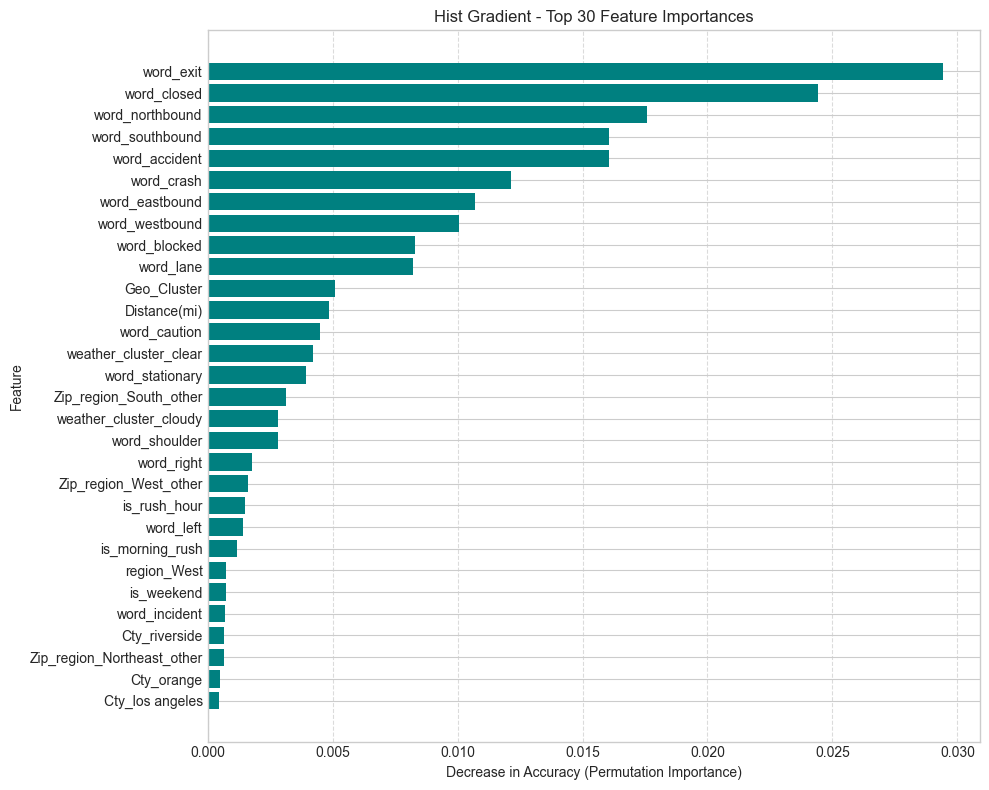

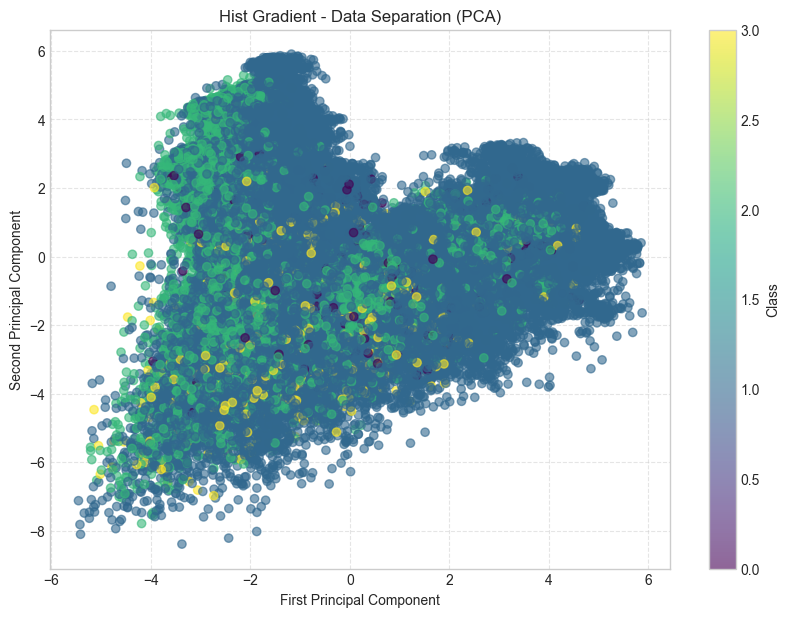

Explained variance ratio (first 2 components): 9.19%


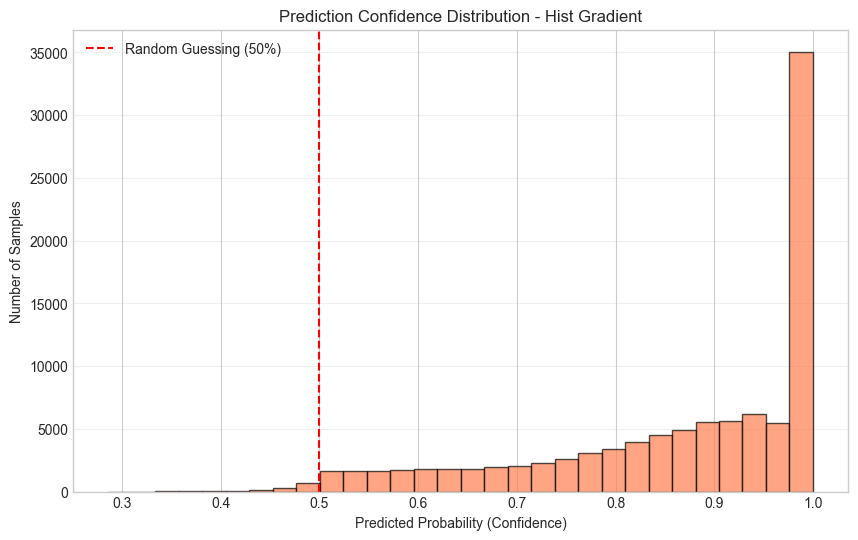

In [11]:
# Execute the model run
hist_results, hist_model = run_hist_gradient_boosting(
    X_train_res, X_test_scaled, y_train_res, y_test
)

# Store for comparison with future models
all_results.append(hist_results)
trained_models['XGBoost'] = hist_model

# XGBClassifier


 MODEL: XGBoost
              precision    recall  f1-score   support

           0       0.37      0.67      0.48       871
           1       0.94      0.90      0.92     79667
           2       0.71      0.78      0.74     16813
           3       0.59      0.82      0.68      2649

    accuracy                           0.88    100000
   macro avg       0.65      0.79      0.71    100000
weighted avg       0.89      0.88      0.88    100000

Confusion Matrix:
[[  583   280     7     1]
 [  932 71935  5314  1486]
 [   39  3661 13065    48]
 [    5   337   140  2167]]


Calculating feature importance for XGBoost...
Top 30 features for XGBoost:
  word_exit: 0.0294
  word_closed: 0.0240
  word_northbound: 0.0176
  word_southbound: 0.0175
  word_accident: 0.0129
  word_crash: 0.0117
  word_eastbound: 0.0115
  word_westbound: 0.0110
  word_lane: 0.0098
  word_blocked: 0.0079
  word_caution: 0.0070
  Geo_Cluster: 0.0068
  Distance(mi): 0.0049
  Zip_region_South_other: 0.0034
  word_stat

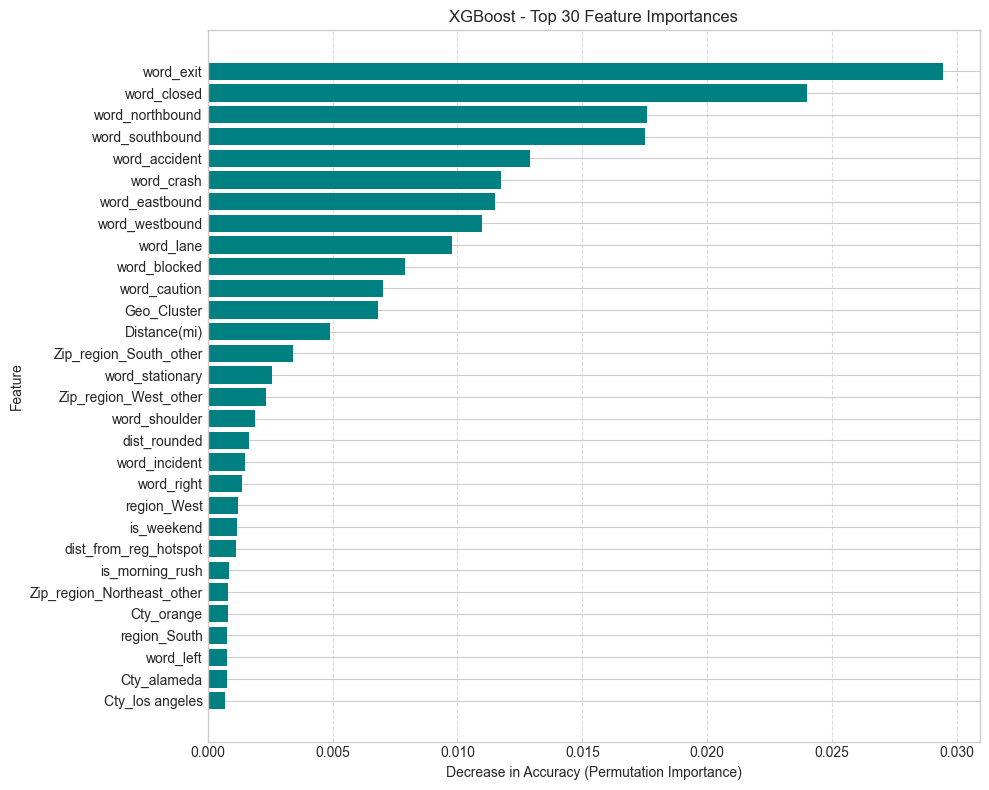

In [ ]:
# Extracts, prints, and plots feature importances
res, mdl = run_xgb_classifier_feature(
    X_train_res, X_test_scaled, y_train_res, y_test, 
    max_depth=6, 
    n_estimators=200
)

# Store for comparison with future models
all_results.append(res)
trained_models['XGBoost'] = mdl

## Decision Tree


 MODEL: Decision Tree
              precision    recall  f1-score   support

           0       0.15      0.72      0.24       871
           1       0.93      0.82      0.87     79667
           2       0.55      0.71      0.62     16813
           3       0.51      0.87      0.64      2649

    accuracy                           0.80    100000
   macro avg       0.53      0.78      0.59    100000
weighted avg       0.85      0.80      0.82    100000

Confusion Matrix:
[[  626   185    59     1]
 [ 3201 64940  9471  2055]
 [  472  4220 11933   188]
 [    4   141   210  2294]]


Calculating feature importance for Decision Tree...
Top 30 features for Decision Tree:
  word_exit: 0.1441
  word_closed: 0.0522
  word_traffic: 0.0441
  Distance(mi): 0.0418
  word_crash: 0.0288
  word_accident: 0.0091
  word_lane: 0.0083
  word_right: 0.0071
  word_left: 0.0039
  Geo_Cluster: 0.0027
  dist_rounded: 0.0011
  is_freezing: 0.0005
  word_shoulder: 0.0001
  Zip_region_South_other: 0.0001
  Cty_me

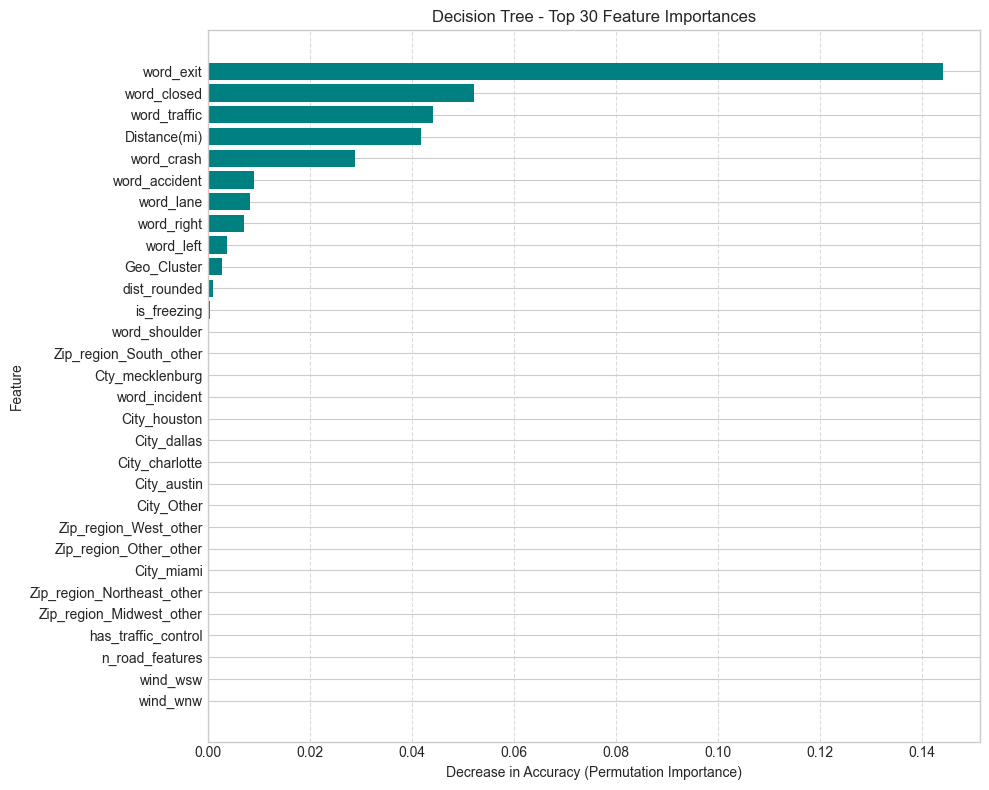

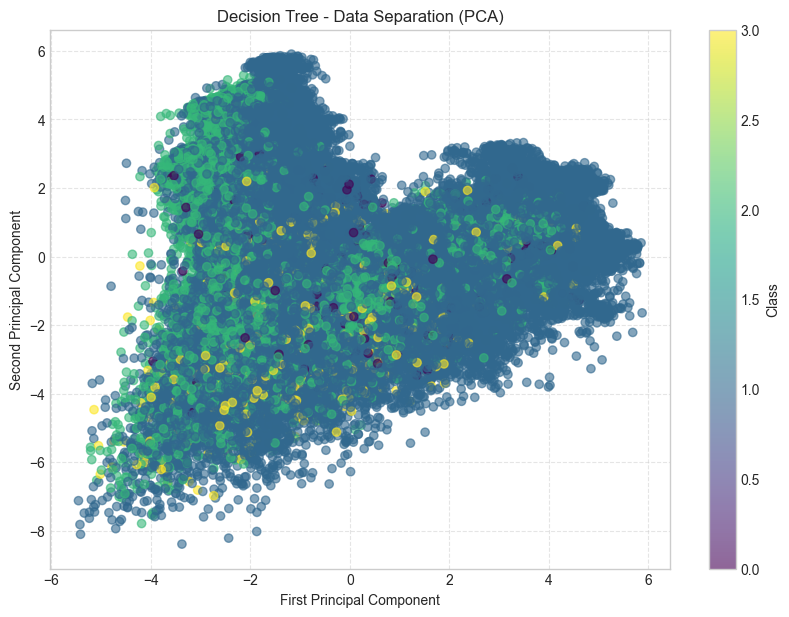

Explained variance ratio (first 2 components): 9.19%


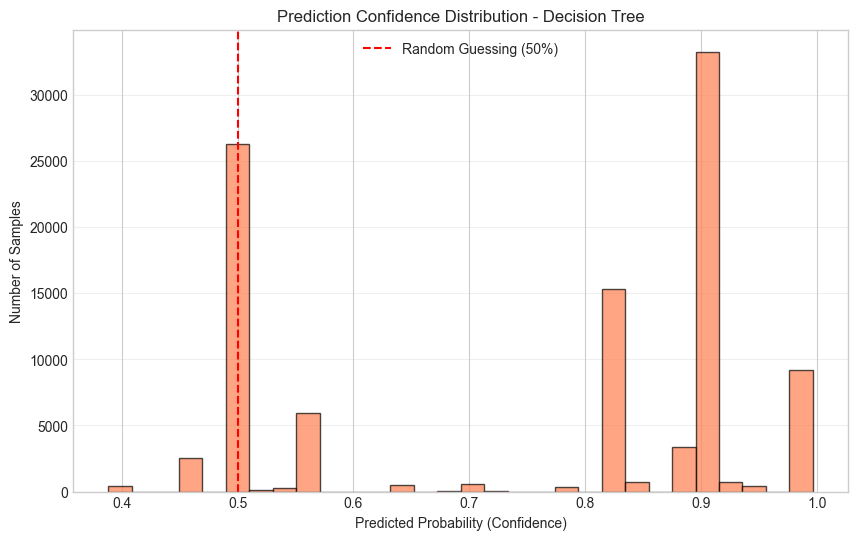

In [ ]:
# Extracts, prints, and plots feature importances
res, mdl = run_decision_tree(X_train_res, X_test_scaled, y_train_res, y_test, max_depth=5)

# Store for comparison with future models
all_results.append(res)
trained_models['Decision Tree'] = mdl

## Random Forest


 MODEL: Random Forest
              precision    recall  f1-score   support

           0       0.18      0.80      0.30       871
           1       0.97      0.79      0.87     79667
           2       0.56      0.87      0.68     16813
           3       0.49      0.88      0.63      2649

    accuracy                           0.81    100000
   macro avg       0.55      0.84      0.62    100000
weighted avg       0.88      0.81      0.83    100000

Confusion Matrix:
[[  696   120    54     1]
 [ 2951 63089 11380  2247]
 [  115  1880 14649   169]
 [    9    95   207  2338]]


Calculating feature importance for Random Forest...
Top 30 features for Random Forest:
  word_exit: 0.0593
  word_closed: 0.0297
  word_accident: 0.0209
  word_crash: 0.0134
  word_blocked: 0.0093
  word_right: 0.0060
  word_lane: 0.0056
  word_shoulder: 0.0048
  Geo_Cluster: 0.0043
  region_West: 0.0027
  word_left: 0.0027
  Zip_region_West_other: 0.0024
  n_road_features: 0.0019
  is_morning_rush: 0.0019
  w

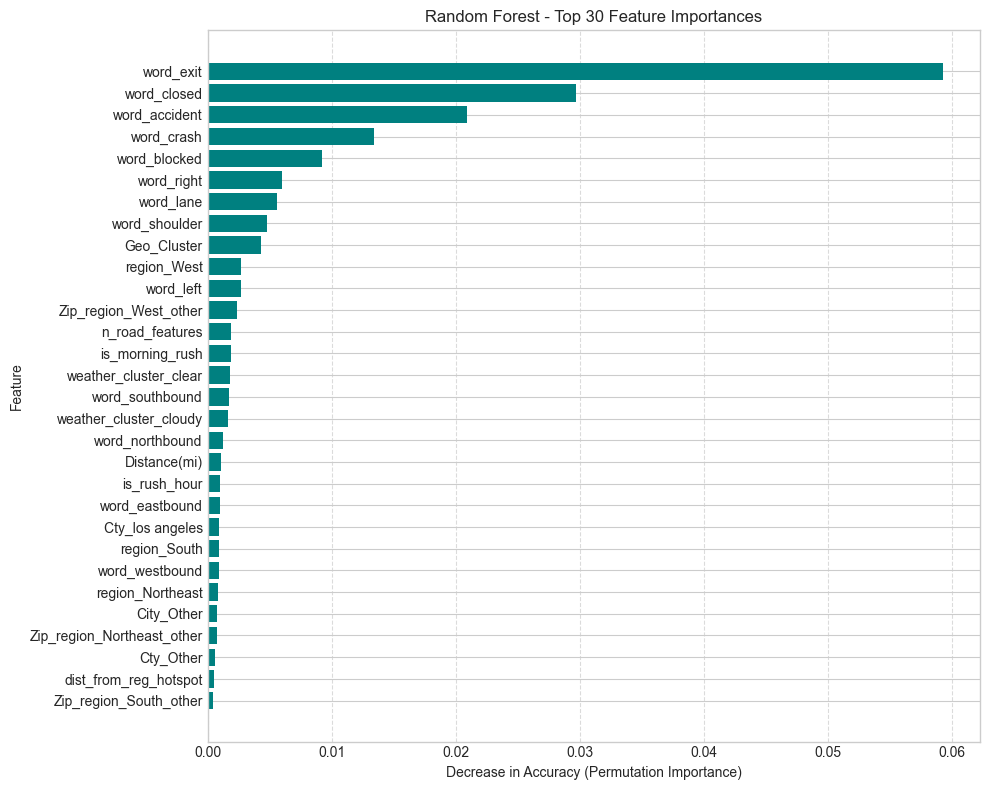

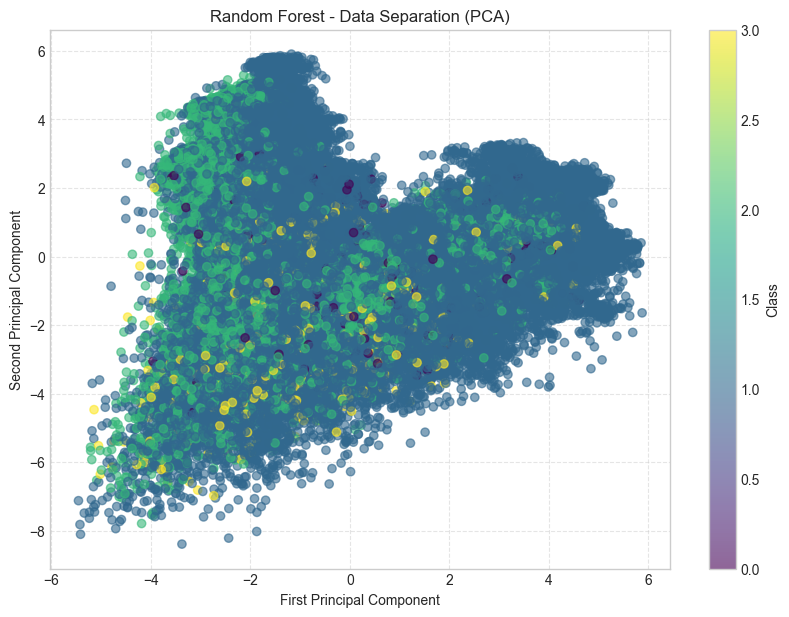

Explained variance ratio (first 2 components): 9.19%


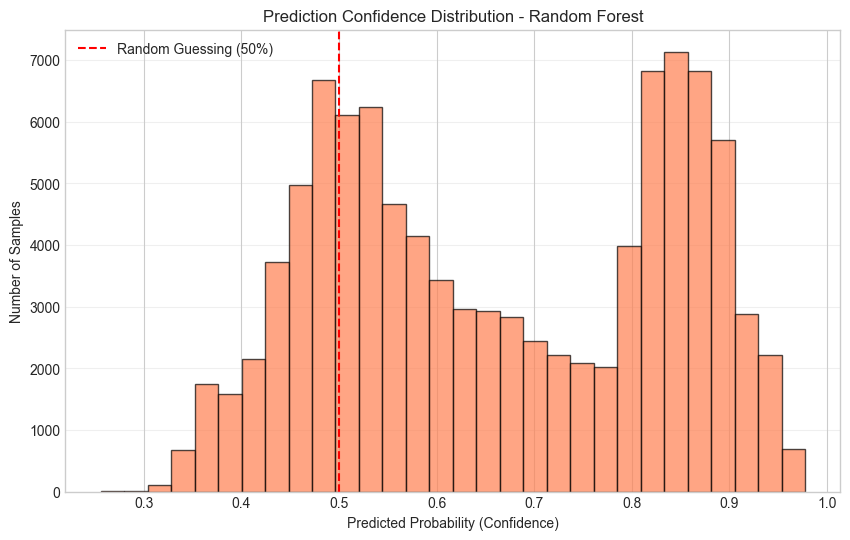

In [14]:
#Parameters for Random Forest - using the trained models from above
params_RF = {'n_estimators': 100, 'max_depth': 10, 'random_state': 42}

#Extracts, prints, and plots feature importances
res, mdl = run_random_forest(X_train_res, X_test_scaled, y_train_res, y_test, **params_RF )

#Store for comparison with future models
all_results.append(res)
trained_models['Random Forest'] = mdl

## K-Nearest Neighbors

In [15]:
# #Parameters for KNN - using the trained models from above
# params_KNN = {'n_neighbors': 5}

# #Extracts, prints, and plots feature importances
# res, mdl = run_knn(X_train_res, X_test_scaled, y_train_res, y_test, **params_KNN)

# #Store for comparison with future models
# all_results.append(res)
# trained_models['KNN'] = mdl

## Gradient Boosting


 MODEL: Gradient Boosting
              precision    recall  f1-score   support

           0       0.34      0.70      0.46       871
           1       0.95      0.89      0.92     79667
           2       0.68      0.78      0.73     16813
           3       0.55      0.85      0.67      2649

    accuracy                           0.87    100000
   macro avg       0.63      0.80      0.69    100000
weighted avg       0.89      0.87      0.87    100000

Confusion Matrix:
[[  608   254     8     1]
 [ 1105 70813  6011  1738]
 [   53  3565 13091   104]
 [    5   260   134  2250]]


Calculating feature importance for Gradient Boosting...
Top 30 features for Gradient Boosting:
  word_closed: 0.0263
  word_exit: 0.0253
  word_southbound: 0.0163
  word_northbound: 0.0163
  word_crash: 0.0122
  word_eastbound: 0.0113
  word_accident: 0.0108
  word_westbound: 0.0106
  Distance(mi): 0.0081
  word_lane: 0.0078
  word_shoulder: 0.0045
  word_blocked: 0.0042
  Geo_Cluster: 0.0036
  word_right:

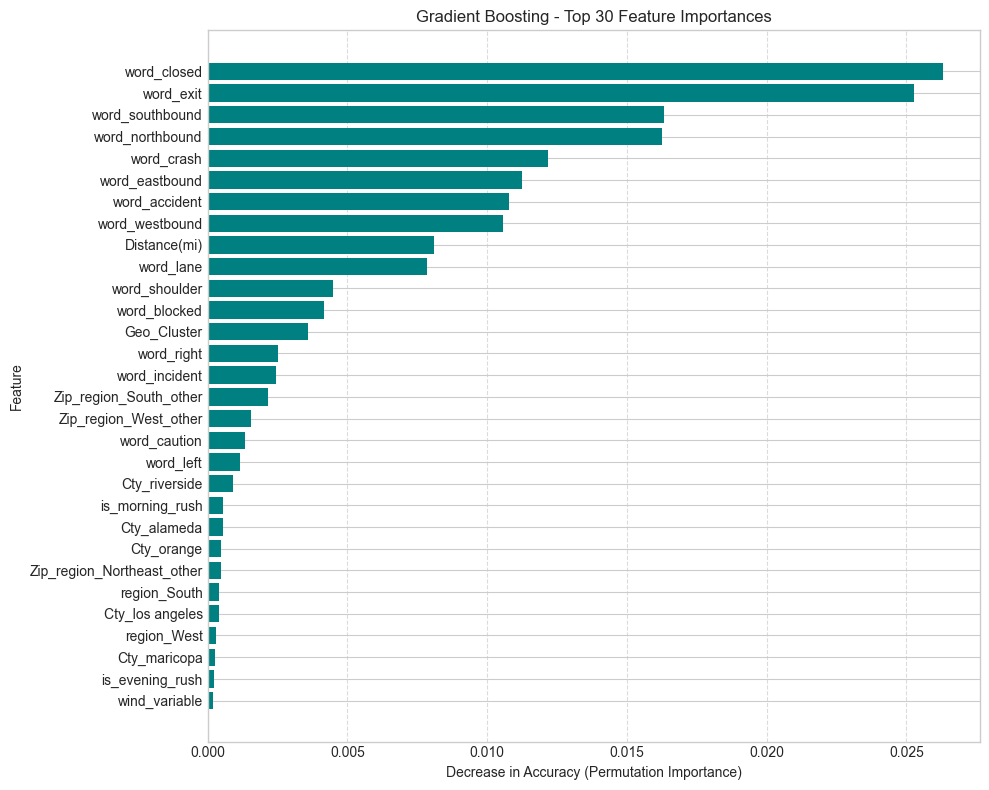

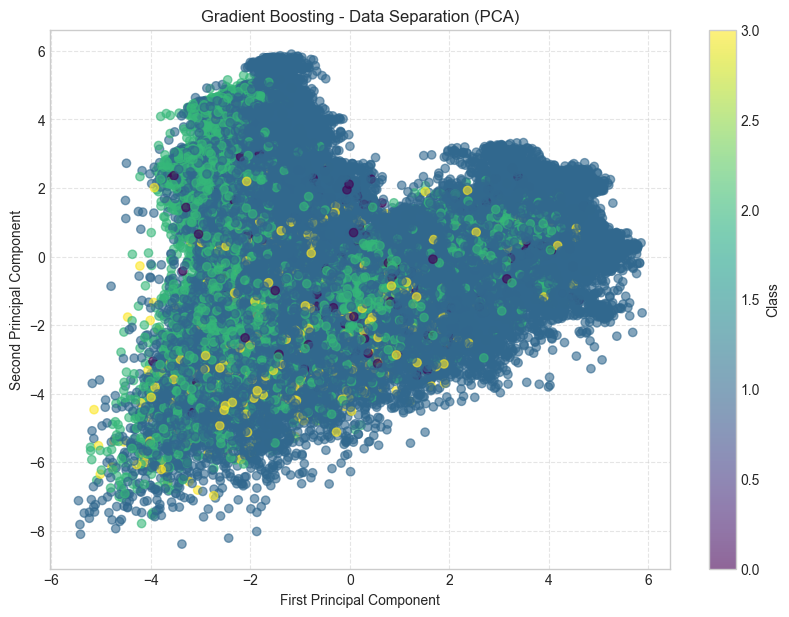

Explained variance ratio (first 2 components): 9.19%


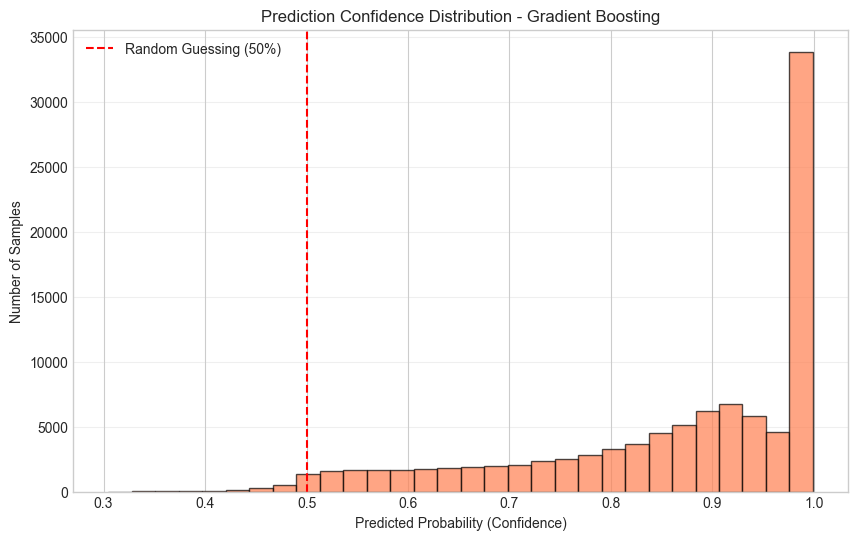

In [ ]:
#Extracts, prints, and plots feature importances
#res, mdl = run_gradient_boosting(X_train_res, X_test_scaled, y_train_res, y_test, n_estimators=100, max_depth=5)

#Store for comparison with future models
#all_results.append(res)
#trained_models['Gradient Boosting'] = mdl

## Voting Classifier


 MODEL: Voting Classifier
              precision    recall  f1-score   support

           0       0.34      0.73      0.47       871
           1       0.95      0.88      0.91     79667
           2       0.67      0.81      0.73     16813
           3       0.54      0.86      0.67      2649

    accuracy                           0.87    100000
   macro avg       0.63      0.82      0.70    100000
weighted avg       0.89      0.87      0.87    100000

Confusion Matrix:
[[  639   216    15     1]
 [ 1171 70108  6528  1860]
 [   48  3069 13626    70]
 [    5   189   165  2290]]


Calculating feature importance for Voting Classifier...
Top 30 features for Voting Classifier:
  word_exit: 0.0256
  word_closed: 0.0231
  word_crash: 0.0124
  word_southbound: 0.0105
  word_northbound: 0.0100
  word_accident: 0.0092
  Geo_Cluster: 0.0082
  word_blocked: 0.0077
  word_lane: 0.0070
  word_westbound: 0.0068
  word_eastbound: 0.0064
  weather_cluster_clear: 0.0046
  weather_cluster_cloudy: 0.

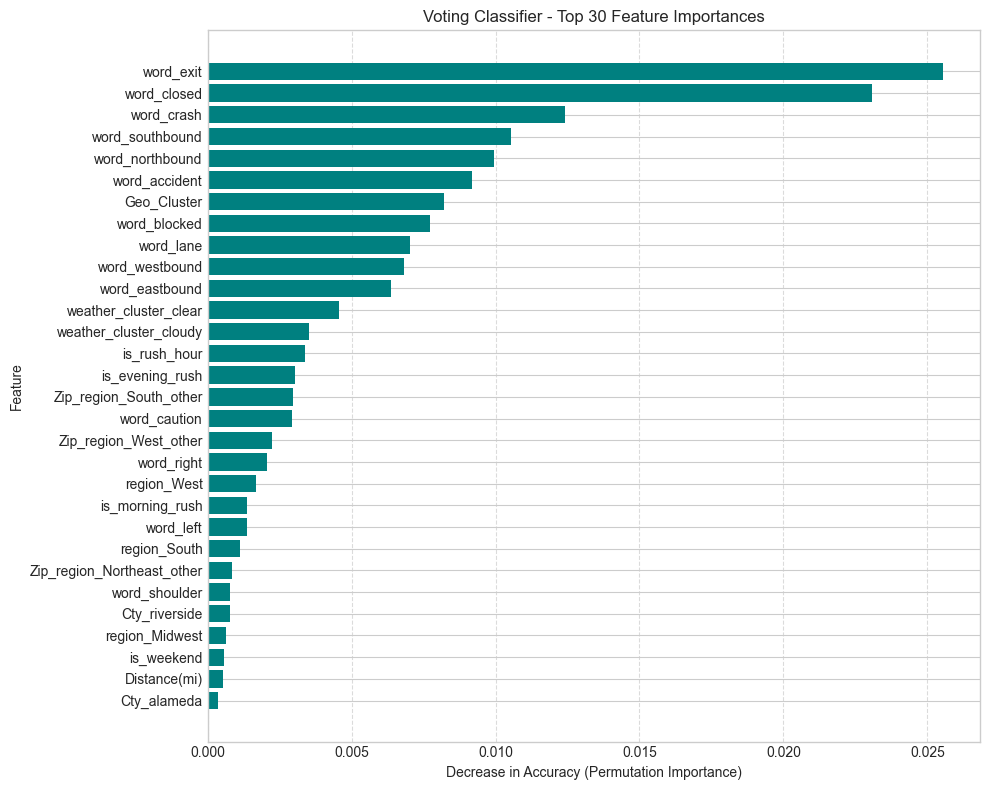

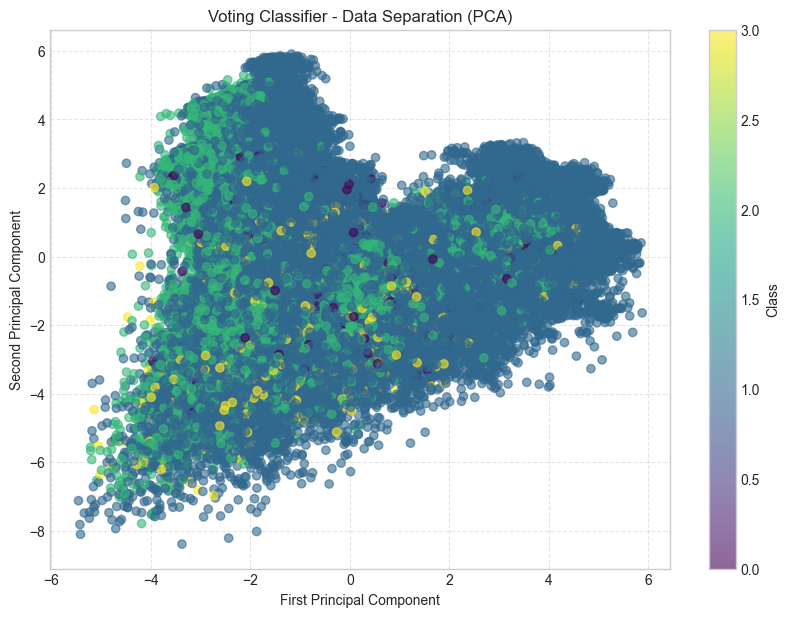

Explained variance ratio (first 2 components): 9.19%


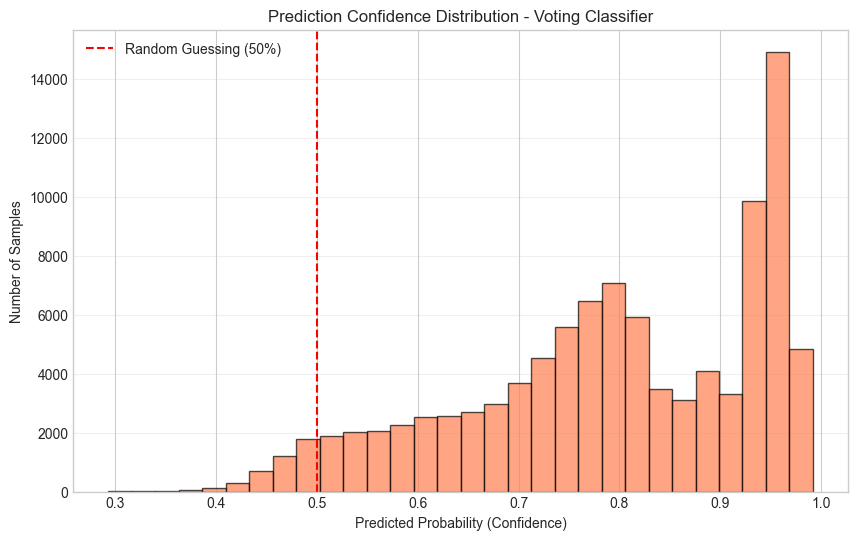

In [26]:
#Parameters for voting classifier - using the trained models from above
estimators_list = [
    ('xgb', XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)),
    ('hist_gb', HistGradientBoostingClassifier(max_iter=100, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42))
]
vote='soft' # 'soft' uses probabilities, 'hard' uses majority vote

#Extracts, prints, and plots feature importances
res_vote, mdl_vote = run_voting_classifier(X_train_res, X_test_scaled, y_train_res, y_test, voting =vote, estimators_list=estimators_list)

#Store for comparison with future models
all_results.append(res_vote)
trained_models['Voting Classifier'] = mdl_vote

## SVM Classification

In [18]:
### This takes a long time to run, so I'm leaving it commented out for now. You can uncomment it when you want to run it.
# #Extracts, prints, and plots feature importances
# res, mdl = run_svm_linear(X_train_res, X_test_scaled, y_train_res, y_test, C=1.0)

# #Store for comparison with future models
# all_results.append(res)
# trained_models['SVM Linear'] = mdl

In [24]:
# Convert the list of results into a formatted table
results_df = pd.DataFrame(all_results)

# Sort by Test F1 to see your best performers at the top
results_df = results_df.sort_values(by='Test F1 (weighted)', ascending=False)

# Display with nice formatting
display(results_df)

,Model,Train Accuracy,Test Accuracy,Train F1 (weighted),Test F1 (weighted),Train Precision,Test Precision
1,XGBoost,0.947031,0.87750,0.946930,0.881863,0.946914,0.889284
0,Hist Gradient,0.940034,0.87105,0.939951,0.876671,0.940007,0.886705
5,Voting Classifier,0.940682,0.86663,0.940545,0.873993,0.941017,0.889082
4,Gradient Boosting,0.936328,0.86762,0.936283,0.873781,0.936427,0.885204
3,Random Forest,0.891994,0.80772,0.892327,0.827593,0.896991,0.879381
2,Decision Tree,0.815958,0.79793,0.818155,0.817006,0.830637,0.851779


In [20]:
# Define path relative to notebook
model_path = "../models/model1_traditional_ml/EW_xgb_model.pkl"

# Create folder if not exists
os.makedirs(os.path.dirname(model_path), exist_ok=True)

# Save model
joblib.dump(trained_models, model_path)

print(f"Model saved to {model_path}")

Model saved to ../models/model1_traditional_ml/EW_xgb_model.pkl
